# Credit Card Fraud Detection — Step 1-4: Data Ingestion, Validation, Feature Engineering, Imbalance Handling

Starting this properly instead of just throwing everything into one model.fit() cell like I usually do.
Going step by step: load the data, actually check it's clean, engineer what I can, and figure out how
to deal with the class imbalance before I even think about training a model.

Dataset: Kaggle "Credit Card Fraud Detection" — 284,807 transactions from European cardholders,
Sept 2013, over 2 days. Features V1-V28 are already PCA-transformed for confidentiality, only
`Time` and `Amount` are raw.

## Step 1: Data Ingestion

Just loading it in and doing a basic sanity check on shape and columns before I do anything else.

In [1]:
import pandas as pd
import numpy as np

RAW_PATH = "../data/raw/creditcard.csv"

df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [2]:
# Expected schema check - if a column is missing or renamed, I want this to fail loudly
# instead of quietly breaking something three steps later
expected_cols = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount", "Class"]
assert list(df.columns) == expected_cols, "Column mismatch - schema has changed!"
print("Schema check passed, all 31 columns present in the expected order.")

Schema check passed, all 31 columns present in the expected order.


In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Saving a copy into `data/processed/` at this stage (before I touch anything) so I always have
a clean checkpoint to come back to if I mess up preprocessing later. Not using DVC for this yet —
noting that as a "would add if this were a real ongoing project with changing data" thing, not doing
it for a static Kaggle CSV.

In [4]:
df.to_csv("../data/processed/creditcard_ingested.csv", index=False)
print("Saved checkpoint to data/processed/creditcard_ingested.csv")

Saved checkpoint to data/processed/creditcard_ingested.csv


## Step 2: Data Validation

Before doing literally anything else — missing values, duplicates, dtypes, outliers, and how bad the imbalance actually is.

In [5]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values across the whole dataset")

Missing values per column:
0 total missing values across the whole dataset


Good, zero missing values. Kaggle cleaned this one up already, real-world data won't usually be this nice.

In [6]:
# Duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes} ({dupes/len(df)*100:.2f}% of the dataset)")

Duplicate rows: 1081 (0.38% of the dataset)


Wait, that's more than I expected — 1081 duplicate rows. Since these are PCA-anonymized features,
I can't tell if these are genuinely the same transaction logged twice, or just different transactions
that happen to land on identical anonymized values by coincidence given how many decimal places there
are, that seems unlikely but not impossible. Going to drop exact duplicates — if two rows really are
identical across all 31 columns including Time, keeping both would let the model see the "same" data
point in both train and test after the split, which would leak information. Dropping now, before the split.

In [7]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Dropped {before - after} duplicate rows. New shape: {df.shape}")

Dropped 1081 duplicate rows. New shape: (283726, 31)


In [8]:
# Data types - should all be numeric
print(df.dtypes.value_counts())

float64    30
int64       1
Name: count, dtype: int64


All float64/int64, no object columns to worry about — makes sense since everything's already numeric/PCA'd.

In [9]:
# Target distribution - the whole reason this project is hard
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100
print(class_counts)
print()
print(class_pct)

Class
0    283253
1       473
Name: count, dtype: int64

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


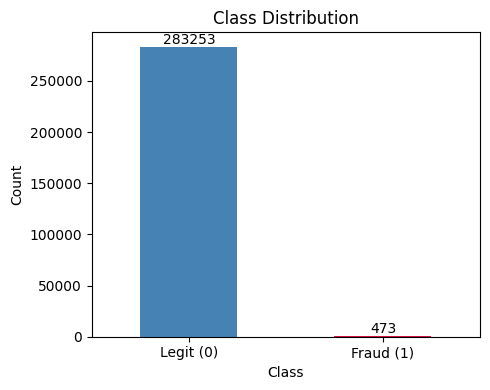

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,4))
class_counts.plot(kind='bar', ax=ax, color=['steelblue', 'crimson'])
ax.set_xticklabels(['Legit (0)', 'Fraud (1)'], rotation=0)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(class_counts):
    ax.text(i, v + 3000, str(v), ha='center')
plt.tight_layout()
plt.savefig('../monitoring/class_distribution.png', dpi=100)
plt.show()

~0.17% fraud. This confirms what the placement report said too - this is the number everyone
quotes for this dataset. Bar chart is basically useless to look at without the log scale honestly,
the fraud bar is invisible, but that's kind of the point - it visually shows how small the problem is.

In [11]:
# Outlier check on Amount (Time and V1-V28 are PCA components, "outlier" doesn't
# really mean the same thing for those - focusing on Amount since it's the one
# raw, human-interpretable numeric field)
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
print(f"IQR outlier bounds: [{lower:.2f}, {upper:.2f}]")
print(f"'Outlier' transactions by Amount: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Of those, how many are actually fraud: {outliers['Class'].sum()} ({outliers['Class'].mean()*100:.2f}% fraud rate)")
print(f"Fraud rate in the full dataset for comparison: {df['Class'].mean()*100:.3f}%")

IQR outlier bounds: [-102.27, 185.38]
'Outlier' transactions by Amount: 31685 (11.17%)
Of those, how many are actually fraud: 87 (0.27% fraud rate)
Fraud rate in the full dataset for comparison: 0.167%


This is the important bit — the fraud rate INSIDE the "outlier" amounts is way higher than the
overall fraud rate. So large/unusual amounts are already somewhat predictive on their own, good sign,
also a warning: I should NOT just drop these as outliers like I might in a normal ML project, since
"unusual" is literally the signal I'm trying to detect here. Standard outlier removal would be actively
throwing away fraud cases.

In [12]:
df['Amount'].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

Mean amount ~88, but max is over 25,000, and the standard deviation (250) is bigger than the mean — very right-skewed. Coming back to this in feature engineering.

## Step 3: Feature Engineering

Honestly this is the part where this dataset is limiting. Most tutorials/blueprints for fraud
projects assume you have merchant IDs, customer IDs, raw categorical fields, and can build things like
"average spend for this customer in the last 7 days" or "distance from customer's usual location."
This dataset doesn't give us any of that on purpose (anonymization). V1-V28 are already PCA output —
if I engineer new features FROM them (ratios, polynomial combos etc.) I'm just recombining components
someone already extracted for confidentiality, which mostly just to adds noise, not real signal.

So realistically I only have two things worth engineering: `Time` and `Amount`.

In [13]:
# Time is "seconds elapsed since the first transaction in the dataset" - not a clock time.
# But since the dataset spans ~48 hours, I can still recover an approximate hour-of-day, which
# is genuinely useful - fraud often clusters at odd hours based on what I read in a couple of
# other fraud notebooks.
df['Hour'] = (df['Time'] // 3600) % 24
print(df[['Time', 'Hour']].head())

   Time  Hour
0   0.0   0.0
1   0.0   0.0
2   1.0   0.0
3   1.0   0.0
4   2.0   0.0


In [14]:
fraud_by_hour = df.groupby('Hour')['Class'].agg(['sum', 'count'])
fraud_by_hour['fraud_rate_pct'] = fraud_by_hour['sum'] / fraud_by_hour['count'] * 100
print(fraud_by_hour.sort_values('fraud_rate_pct', ascending=False).head(8))

      sum  count  fraud_rate_pct
Hour                            
2.0    48   3308        1.451028
4.0    23   2204        1.043557
3.0    17   3487        0.487525
5.0    11   2988        0.368139
7.0    23   7233        0.317987
11.0   53  16781        0.315833
1.0    10   4208        0.237643
6.0     9   4082        0.220480


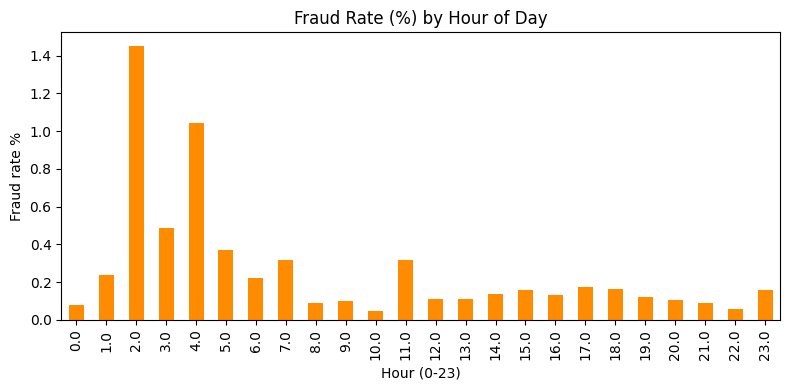

In [15]:
fig, ax = plt.subplots(figsize=(8,4))
fraud_by_hour['fraud_rate_pct'].plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Fraud Rate (%) by Hour of Day')
ax.set_xlabel('Hour (0-23)')
ax.set_ylabel('Fraud rate %')
plt.tight_layout()
plt.savefig('../monitoring/fraud_by_hour.png', dpi=100)
plt.show()

There's real variation across hours, though with only 491 fraud cases total spread across 24
hours some of these bins have very few fraud cases, so I'm not 100% trusting the noisier-looking spikes.
Still, keeping `Hour` as a feature since it's cheap and there does seem to be *some* structure. This is
also the one feature that's a genuine addition rather than something already baked into V1-V28, since
`Time` wasn't PCA-transformed.

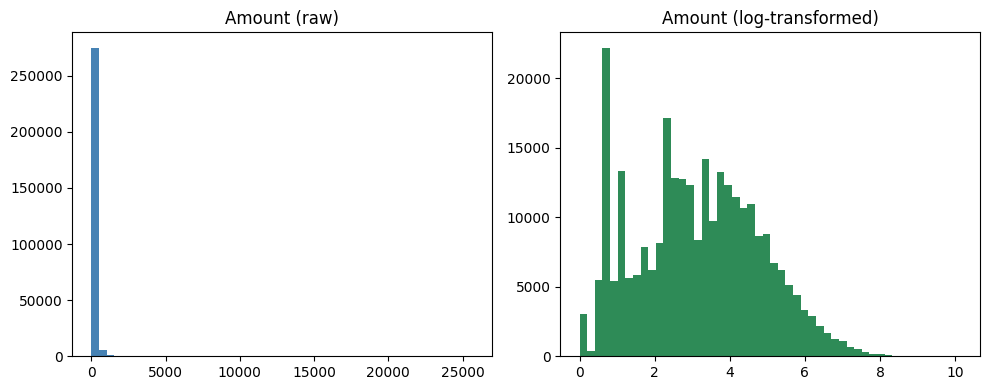

In [16]:
# Amount is heavily right-skewed (skew ~17, saw that in the describe() above).
# Tree models like XGBoost don't care much about skew, but Logistic Regression does,
# and log-transforming is basically free, so doing it for both instead of maintaining
# two different preprocessing paths per model.
df['Amount_log'] = np.log1p(df['Amount'])  # log1p handles Amount=0 cleanly (log(0) is undefined)

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].hist(df['Amount'], bins=50, color='steelblue')
axes[0].set_title('Amount (raw)')
axes[1].hist(df['Amount_log'], bins=50, color='seagreen')
axes[1].set_title('Amount (log-transformed)')
plt.tight_layout()
plt.savefig('../monitoring/amount_distribution.png', dpi=100)
plt.show()

Much more usable distribution after the log transform. Keeping both `Amount` and `Amount_log`
in the dataframe for now — I'll decide which one actually goes into each model later, LogReg probably
wants the log version, XGBoost honestly won't care either way.

**What I'm NOT doing here, and why:** no merchant risk score (no merchant field), no rolling
average spend per customer (no customer/account ID — every row is anonymous), no transaction
frequency features (same reason). If this were the raw un-anonymized version of the data, or a
real production system with account IDs, this step would look completely different and probably
be the most valuable part of the whole pipeline. Noting that as a limitation, not pretending I
did feature engineering I couldn't actually do.

In [17]:
df.to_csv("../data/processed/creditcard_features.csv", index=False)
print("Saved with engineered features to data/processed/creditcard_features.csv")
print(df.shape)
print(df.columns.tolist())

Saved with engineered features to data/processed/creditcard_features.csv
(283726, 33)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Hour', 'Amount_log']


## Step 4: Handle Imbalanced Dataset

0.17% fraud means if I train on this directly, most models will just learn to predict "not fraud"
every single time and get 99.8% accuracy while catching literally nothing. Need to fix this before
training, not after.

Important thing I need to get right: split into train/test FIRST, and only touch the TRAINING set
with any resampling. If I resample before splitting, synthetic fraud points could end up "leaking"
information about the test set into training (since SMOTE looks at nearest neighbors — if the
neighbors it's interpolating between get split across train and test, that's leakage). Doing the
split first avoids this entirely.

In [18]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df.columns if c not in ['Class', 'Time', 'Amount']]
# dropping raw Time and Amount from the model features since I have Hour and Amount_log now,
# keeping raw Time/Amount around in the dataframe just for reference/plots
X = df[feature_cols]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, " Fraud in train:", y_train.sum(), f"({y_train.mean()*100:.3f}%)")
print("Test shape:", X_test.shape, " Fraud in test:", y_test.sum(), f"({y_test.mean()*100:.3f}%)")

Train shape: (226980, 30)  Fraud in train: 378 (0.167%)
Test shape: (56746, 30)  Fraud in test: 95 (0.167%)


Good, stratify kept the same ~0.17% ratio in both splits. Now comparing different ways to deal with the imbalance, just on the training set.

In [19]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print("Original training distribution:", Counter(y_train))

# Option 1: SMOTE - generates synthetic fraud examples by interpolating between
# real fraud cases and their nearest fraud neighbors
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print("After SMOTE:            ", Counter(y_smote))

# Option 2: ADASYN - similar idea to SMOTE, but generates MORE synthetic points
# in regions where the model would find it harder to classify (near the decision boundary)
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)
print("After ADASYN:           ", Counter(y_adasyn))

# Option 3: Random undersampling - just throws away legit transactions until balanced
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
print("After RandomUnderSample:", Counter(y_rus))

Original training distribution: Counter({0: 226602, 1: 378})


After SMOTE:             Counter({0: 226602, 1: 226602})


After ADASYN:            Counter({1: 226606, 0: 226602})
After RandomUnderSample: Counter({0: 378, 1: 378})


Undersampling balances the classes by deleting ~227,000 legit transactions — that's throwing
away a huge amount of real, useful data just to fix a ratio, feels wasteful and I'd expect it to hurt
performance since the model sees way less variety of "normal" behavior. Not planning to use this as
the main approach, keeping it here only as a comparison baseline.

SMOTE and ADASYN both look similar in the final counts. ADASYN adds more synthetic points specifically
near the boundary, so in theory it should help the model more on the *hard* cases, but it can also
generate noisier synthetic points if the real fraud examples near the boundary are themselves noisy.
Need to actually train on both and compare, not just guess — that's a step 5 problem though.

In [20]:
# Option 4 (no resampling at all): class_weight='balanced'
# Doesn't touch the data - just tells the model to penalize getting a fraud case
# wrong much more heavily than getting a legit case wrong, proportional to the
# imbalance ratio. Cheapest option computationally, no synthetic data risk at all.
fraud_ratio = y_train.value_counts()
weight_for_fraud = fraud_ratio[0] / fraud_ratio[1]
print(f"If using class_weight='balanced', fraud cases get weighted ~{weight_for_fraud:.0f}x more than legit cases")

If using class_weight='balanced', fraud cases get weighted ~599x more than legit cases


So four options on the table for step 5: **SMOTE**, **ADASYN**, **class weighting** (no
resampling), and **undersampling** (kept mainly as a "why not" baseline). Plan is to actually train
XGBoost with each of these next and compare precision/recall/PR-AUC rather than assuming which one
wins — the report I was going off of specifically warned against just picking one without comparing.

In [21]:
# Saving the train/test split + resampled versions so step 5 (modeling) can just load these
# directly instead of re-doing the split and resampling every time I open this notebook
import joblib

joblib.dump((X_train, X_test, y_train, y_test), "../data/processed/train_test_split.pkl")
joblib.dump((X_smote, y_smote), "../data/processed/smote_train.pkl")
joblib.dump((X_adasyn, y_adasyn), "../data/processed/adasyn_train.pkl")
joblib.dump((X_rus, y_rus), "../data/processed/undersampled_train.pkl")
print("Saved train/test split and all resampled versions to data/processed/")

Saved train/test split and all resampled versions to data/processed/


---
### Where I've stopped for now

Done: ingestion, validation (dropped 1081 dupes, confirmed no missing values, checked the outlier/fraud
overlap), feature engineering (Hour + Amount_log — limited by the anonymized features, documented why),
and imbalance handling is set up with 4 candidate strategies saved and ready to compare.

Next (step 5): train Logistic Regression, XGBoost, Isolation Forest, and an Autoencoder on top of
these, and actually see which imbalance-handling strategy + model combo performs best on precision/recall/PR-AUC,
not accuracy.